In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

In [2]:
df_model = pd.read_csv("data/processed/accepted_model_base.csv")
print(df_model.shape)
df_model.head()

(1371166, 25)


,loan_amnt,term,installment,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,...,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years,loan_status,target_bad
0,3600.0,36.0,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,debt_consolidation,...,0.0,2765.0,29.7,13.0,1.0,0.0,677.0,12.334018,Fully Paid,0
1,24700.0,36.0,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,small_business,...,0.0,21470.0,19.2,38.0,4.0,0.0,717.0,16.000000,Fully Paid,0
2,20000.0,60.0,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,2015-12-01,home_improvement,...,0.0,7869.0,56.2,18.0,5.0,0.0,697.0,15.331964,Fully Paid,0
3,10400.0,60.0,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,2015-12-01,major_purchase,...,0.0,21929.0,64.5,35.0,6.0,0.0,697.0,17.500342,Fully Paid,0
4,11950.0,36.0,405.18,C,4 years,RENT,34000.0,Source Verified,2015-12-01,debt_consolidation,...,0.0,8822.0,68.4,6.0,0.0,0.0,692.0,28.167009,Fully Paid,0


In [3]:
df_model["issue_d"] = pd.to_datetime(df_model["issue_d"], errors="coerce")

In [4]:
train_df = df_model[df_model["issue_d"] < "2016-01-01"].copy()
valid_df = df_model[(df_model["issue_d"] >= "2016-01-01") & (df_model["issue_d"] < "2017-01-01")].copy()
test_df = df_model[df_model["issue_d"] >= "2017-01-01"].copy()

print(train_df.shape, valid_df.shape, test_df.shape)

(828654, 25) (298553, 25) (243959, 25)


In [5]:
print(train_df["issue_d"].min(), train_df["issue_d"].max())
print(valid_df["issue_d"].min(), valid_df["issue_d"].max())
print(test_df["issue_d"].min(), test_df["issue_d"].max())

2007-06-01 00:00:00 2015-12-01 00:00:00
2016-01-01 00:00:00 2016-12-01 00:00:00
2017-01-01 00:00:00 2018-12-01 00:00:00


In [6]:
print(df_model["issue_d"].min())
print(df_model["issue_d"].max())
print(df_model["issue_d"].dt.year.value_counts().sort_index())

2007-06-01 00:00:00
2018-12-01 00:00:00
issue_d
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134807
2014    223510
2015    377184
2016    298553
2017    178817
2018     65142
Name: count, dtype: int64


In [7]:
drop_cols = ["loan_status", "target_bad", "issue_d"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["target_bad"]

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df["target_bad"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["target_bad"]

In [8]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['loan_amnt', 'term', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'fico_avg', 'credit_history_years']
Categorical: ['grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']


In [9]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

In [10]:
logit_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

logit_model.fit(X_train, y_train)

valid_pred_logit = logit_model.predict_proba(X_valid)[:, 1]
test_pred_logit = logit_model.predict_proba(X_test)[:, 1]

print("Validation ROC AUC:", roc_auc_score(y_valid, valid_pred_logit))
print("Validation PR AUC:", average_precision_score(y_valid, valid_pred_logit))
print("Test ROC AUC:", roc_auc_score(y_test, test_pred_logit))
print("Test PR AUC:", average_precision_score(y_test, test_pred_logit))

Validation ROC AUC: 0.7073383932711508
Validation PR AUC: 0.4334768906010599
Test ROC AUC: 0.6932607930698692
Test PR AUC: 0.43367952855294906


In [11]:
test_label_logit = (test_pred_logit >= 0.5).astype(int)

print(confusion_matrix(y_test, test_label_logit))
print(classification_report(y_test, test_label_logit))

[[175099   2497]
 [ 63004   3359]]
              precision    recall  f1-score   support

           0       0.74      0.99      0.84    177596
           1       0.57      0.05      0.09     66363

    accuracy                           0.73    243959
   macro avg       0.65      0.52      0.47    243959
weighted avg       0.69      0.73      0.64    243959



In [12]:
from sklearn.metrics import confusion_matrix, classification_report

for thresh in [0.15, 0.20, 0.25, 0.30, 0.35]:
    preds = (test_pred_logit >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    print(f"\nThreshold = {thresh}")
    print(cm)
    print(classification_report(y_test, preds, digits=3))


Threshold = 0.15
[[93684 83912]
 [16680 49683]]
              precision    recall  f1-score   support

           0      0.849     0.528     0.651    177596
           1      0.372     0.749     0.497     66363

    accuracy                          0.588    243959
   macro avg      0.610     0.638     0.574    243959
weighted avg      0.719     0.588     0.609    243959


Threshold = 0.2
[[122978  54618]
 [ 27999  38364]]
              precision    recall  f1-score   support

           0      0.815     0.692     0.749    177596
           1      0.413     0.578     0.482     66363

    accuracy                          0.661    243959
   macro avg      0.614     0.635     0.615    243959
weighted avg      0.705     0.661     0.676    243959


Threshold = 0.25
[[143403  34193]
 [ 38419  27944]]
              precision    recall  f1-score   support

           0      0.789     0.807     0.798    177596
           1      0.450     0.421     0.435     66363

    accuracy                

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

rows = []
for thresh in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]:
    preds = (test_pred_logit >= thresh).astype(int)
    rows.append({
        "threshold": thresh,
        "accuracy": accuracy_score(y_test, preds),
        "precision_bad": precision_score(y_test, preds, zero_division=0),
        "recall_bad": recall_score(y_test, preds, zero_division=0),
        "f1_bad": f1_score(y_test, preds, zero_division=0),
        "flag_rate": preds.mean()
    })

threshold_results = pd.DataFrame(rows)
threshold_results

,threshold,accuracy,precision_bad,recall_bad,f1_bad,flag_rate
0,0.10,0.474469,0.329060,0.896976,0.481485,0.741506
1,0.15,0.587668,0.371893,0.748655,0.496934,0.547613
2,0.20,0.661349,0.412596,0.578093,0.481521,0.381138
3,0.25,0.702360,0.449716,0.421078,0.434926,0.254703
4,0.30,0.721010,0.479261,0.295812,0.365827,0.167901
5,0.35,0.729787,0.508208,0.206184,0.293353,0.110363


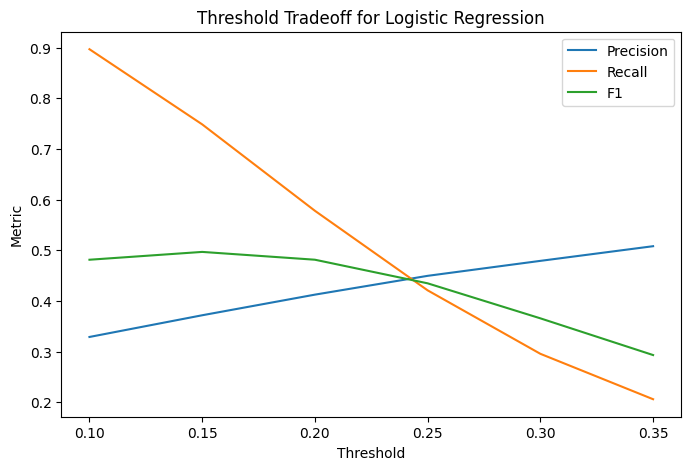

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision_bad"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall_bad"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1_bad"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold Tradeoff for Logistic Regression")
plt.legend()
plt.show()

In [15]:
test_results = test_df.copy()
test_results["pred_logit"] = test_pred_logit
test_results["decile"] = pd.qcut(test_results["pred_logit"], 10, labels=False, duplicates="drop")

decile_summary = test_results.groupby("decile").agg(
    n=("target_bad", "size"),
    avg_pred=("pred_logit", "mean"),
    actual_bad_rate=("target_bad", "mean")
).reset_index()

decile_summary

,decile,n,avg_pred,actual_bad_rate
0,0,24396,0.039253,0.063166
1,1,24396,0.067695,0.122438
2,2,24396,0.097399,0.167241
3,3,24396,0.123539,0.207247
4,4,24396,0.149573,0.245696
5,5,24395,0.178211,0.281369
6,6,24396,0.211169,0.326406
7,7,24396,0.253099,0.374447
8,8,24396,0.315790,0.417404
9,9,24396,0.457682,0.514838


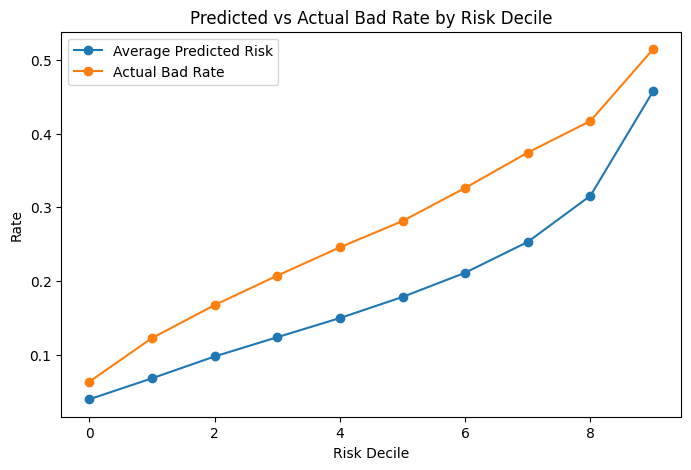

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(decile_summary["decile"], decile_summary["avg_pred"], marker="o", label="Average Predicted Risk")
plt.plot(decile_summary["decile"], decile_summary["actual_bad_rate"], marker="o", label="Actual Bad Rate")
plt.xlabel("Risk Decile")
plt.ylabel("Rate")
plt.title("Predicted vs Actual Bad Rate by Risk Decile")
plt.legend()
plt.show()

In [17]:
import pandas as pd
from pathlib import Path

out_dir = Path("data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "y_valid": y_valid.reset_index(drop=True),
    "pred_logit": pd.Series(valid_pred_logit).reset_index(drop=True),
}).to_csv(out_dir / "logit_valid_predictions.csv", index=False)

pd.DataFrame({
    "y_test": y_test.reset_index(drop=True),
    "pred_logit": pd.Series(test_pred_logit).reset_index(drop=True),
}).to_csv(out_dir / "logit_test_predictions.csv", index=False)